In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# Importing the data
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.1307,),
        std=(0.3081,)
    )
])

In [4]:
# Separately loading the training and test data using the MNIST dataset from torchvision. The data will be downloaded to the 'data' folder if it is not already there. We also apply a transformation to convert the images to tensors and normalize the pixel values to be between 0 and 1 (instead of 0-255).
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='data', train=False, download=True, transform=transform)
x_train = train_data.data.float().unsqueeze(1) / 255.0  # Add channel dimension: (N, 28, 28) -> (N, 1, 28, 28)
y_train = train_data.targets.long()
x_test = test_data.data.float().unsqueeze(1) / 255.0  # Add channel dimension: (N, 28, 28) -> (N, 1, 28, 28)
y_test = test_data.targets.long()

In [5]:
x_train[0] #Single Image (28x28 pixel values, each value between 0-255)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [6]:
y_train #Output data: Label of the image (0-9)

tensor([5, 0, 4,  ..., 5, 6, 8])

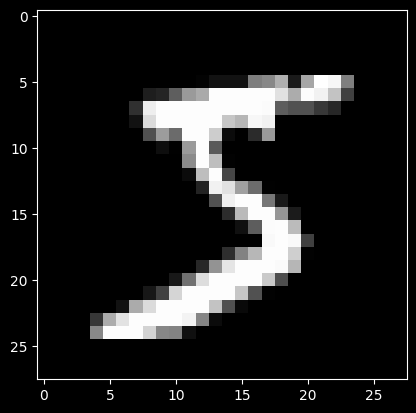

In [7]:
plt.imshow(x_train[0].squeeze(), cmap='gray') #Plotting the first image in the training data

In [8]:
# Building the model - CNN architecture for image classification
class MNISTModel(nn.Module):
    def __init__(self):
        super(MNISTModel, self).__init__()

        # First convolutional layer: takes 1-channel grayscale image (28x28) and outputs 32 channels using a 3x3 kernel. This layer learns to detect low-level features like edges and textures.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # Batch normalization for convolutional layer to normalize activations and improve training stability
        self.dropout1 = nn.Dropout(0.25)  # Dropout layer to prevent overfitting

        # Second convolutional layer: takes 32 channels and outputs 64 channels using a 3x3 kernel. This layer learns more complex features by combining low-level features.
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.dropout2 = nn.Dropout(0.25)

        # Max pooling layer: reduces spatial dimensions by half (28x28 -> 14x14) to reduce computation and make features more robust.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional layer: takes 64 channels and outputs 128 channels for even more complex feature learning.
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.dropout3 = nn.Dropout(0.25)

        # Flatten layer: converts 2D convolutional feature maps into a 1D vector for the dense layers. After two max pooling operations, spatial dimensions are 7x7 with 128 channels.
        self.flatten = nn.Flatten()

        # Dense layers to combine learned features and make final predictions
        self.fc1 = nn.Linear(128 * 7 * 7, 256)  # 128 channels * 7x7 spatial dimensions = 6272 features
        self.bn4 = nn.BatchNorm1d(256)
        self.dropout4 = nn.Dropout(0.5)

        # Output layer: 10 neurons for 10 digit classes (0-9)
        self.fc2 = nn.Linear(256, 10)

    # The forward method defines how the input data flows through the layers. Input images go through convolutional layers (which detect spatial features), pooling layers (which reduce dimensions), then dense layers (which make final predictions).
    def forward(self, x):
        # First convolutional block
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        # Max pooling to reduce spatial dimensions
        x = self.pool(x)

        # Second convolutional block
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        # Max pooling to reduce spatial dimensions further
        x = self.pool(x)

        # Third convolutional block
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)

        # Flatten and dense layers
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.bn4(x)
        x = F.relu(x)
        x = self.dropout4(x)

        # Output with softmax activation to get probabilities for each class
        x = F.softmax(self.fc2(x), dim=1)
        return x

In [10]:
# Instantiate model
torch.manual_seed(42)
#device = torch.device("cuda")
device  = torch.device("cpu")

model = MNISTModel()

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Creating data loaders for training and testing data. Data loaders are used to load the data in batches during training, which helps to speed up the training process and allows us to use larger datasets that may not fit into memory all at once. We set shuffle=True for the training data to ensure that the model sees the data in a different order each epoch, which can help to improve generalization.
train_dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader: # Loop through the training data in batches
        optimizer.zero_grad() # Clear the gradients from the previous step to prevent accumulation
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Compute the gradients of the loss with respect to the model's parameters
        optimizer.step() # Update the model's parameters using the computed gradients

        running_loss += loss.item() # Accumulate the loss for this epoch to compute the average loss later
        _, predicted = torch.max(outputs, 1) # Get the predicted class by finding the index of the maximum output value for each sample in the batch
        total += labels.size(0) # Update the total number of samples seen so far (the batch size)
        correct += (predicted == labels).sum().item() # Update the count of correct predictions by comparing the predicted classes to the true labels and summing the number of matches

    accuracy = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")

Epoch 5/5, Loss: 1.4731, Accuracy: 98.94%


In [11]:
# After training the model, we can evaluate its performance on the test set to see how well it generalizes to unseen data. We disable gradients during evaluation since we are not updating the model's parameters, which can speed up the evaluation process and reduce memory usage.
model.eval()
with torch.no_grad():  # disable gradients for evaluation
    predicted = model(x_test)          # pass in test images
    test_loss = criterion(predicted, y_test)  # compute loss
    _, predicted_classes = torch.max(predicted, 1)  # get class predictions
    test_accuracy = (predicted_classes == y_test).float().mean() * 100  # accuracy in percent

print(f'Test Loss: {test_loss.item():.4f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Loss: 1.4724
Test Accuracy: 99.02%
